In [1]:
from transformers import ViTImageProcessor, ViTModel
from PIL import Image
import requests

url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
image = Image.open(requests.get(url, stream=True).raw)

processor = ViTImageProcessor.from_pretrained('google/vit-large-patch16-224-in21k')
model = ViTModel.from_pretrained('google/vit-large-patch16-224-in21k')

inputs = processor(images=image, return_tensors="pt")
outputs = model(**inputs)
last_hidden_state = outputs.last_hidden_state

/Users/a/miniconda3/envs/f2f/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 392/392 [00:00<00:00, 6628.13it/s]


In [30]:
outputs

BaseModelOutputWithPooling(last_hidden_state=tensor([[[ 0.4019,  0.0466, -0.0509,  ..., -0.5096,  0.0089,  0.4926],
         [-0.1732,  0.4083,  0.0313,  ...,  0.1868, -0.4092, -0.4049],
         [-0.2973,  0.0146, -0.5703,  ..., -0.1531, -0.1613, -0.1647],
         ...,
         [-0.7139,  0.4041, -0.0601,  ..., -1.0062,  0.0582,  0.4019],
         [-0.2561,  0.0299, -0.3649,  ...,  0.2998, -0.5462,  0.2633],
         [ 0.0235,  0.3331,  0.0495,  ..., -0.1067,  0.0560,  0.1693]]],
       grad_fn=<NativeLayerNormBackward0>), pooler_output=tensor([[-0.0305, -0.4376,  0.3284,  ...,  0.1752, -0.2688, -0.6715]],
       grad_fn=<TanhBackward0>), hidden_states=None, attentions=None)

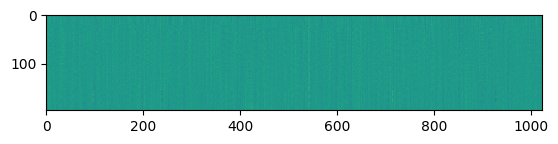

In [32]:
import matplotlib.pyplot as plt
import numpy as np

arr = last_hidden_state.detach().numpy()#This is your tensor
arr_ = np.squeeze(arr) # you can give axis attribute if you wanna squeeze in specific dimension
plt.imshow(arr_)
plt.show()
